# 📊 Alfido Tech TASK-3 — Instagram Engagement Analysis
**Goal:** Identify best posting times, high-engagement content types, and follower growth signals.

---
voonna venkata sai ganesh

---
## 0️⃣ Install & Import Libraries

In [1]:
# Install any missing libraries
!pip install -q plotly kaleido

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import plotly.express as px
import plotly.graph_objects as go
from plotly.subplots import make_subplots
from google.colab import files
import io
import warnings
warnings.filterwarnings('ignore')

# Plotting style
sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['figure.dpi'] = 120
plt.rcParams['font.family'] = 'DejaVu Sans'

BRAND_COLOR = '#E1306C'   # Instagram-ish pink
SEC_COLOR   = '#405DE6'   # Instagram-ish blue
print('✅ Libraries ready.')

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 55.6/55.6 kB 3.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 52.6/52.6 kB 4.2 MB/s eta 0:00:00
✅ Libraries ready.


---
## 1️⃣ Upload & Load Data
### ⬆️ Upload Instructions
When the file picker opens, **select all 7 CSV files at once**:
- `users.csv`
- `photos.csv`
- `likes.csv`
- `comments.csv`
- `follows.csv`
- `tags.csv`
- `photo_tags.csv`

In [2]:
# ⬆️ UPLOAD: Select all 7 CSV files when the picker opens
uploaded = files.upload()

def load(name):
    """Load a CSV from uploaded dict by partial name match."""
    for k in uploaded:
        if name.lower() in k.lower():
            return pd.read_csv(io.BytesIO(uploaded[k]))
    raise FileNotFoundError(f"Could not find file matching '{name}' in uploaded files.")

users      = load('users')
photos     = load('photos')
likes      = load('likes')
comments   = load('comments')
follows    = load('follows')
tags       = load('tags')
photo_tags = load('photo_tags')

print('✅ All 7 files loaded.')
for name, df in [('users', users), ('photos', photos), ('likes', likes),
                  ('comments', comments), ('follows', follows),
                  ('tags', tags), ('photo_tags', photo_tags)]:
    print(f'   {name:12s} → {df.shape[0]:,} rows × {df.shape[1]} cols')

Saving users.csv to users.csv
Saving photos.csv to photos.csv
Saving likes.csv to likes.csv
Saving comments.csv to comments.csv
Saving follows.csv to follows.csv
Saving tags.csv to tags.csv
Saving photo_tags.csv to photo_tags.csv
✅ All 7 files loaded.
   users        → 100 rows × 6 cols
   photos       → 257 rows × 6 cols
   likes        → 8,782 rows × 5 cols
   comments     → 7,488 rows × 8 cols
   follows      → 7,623 rows × 5 cols
   tags         → 21 rows × 4 cols
   photo_tags   → 501 rows × 3 cols


---
## 2️⃣ Data Cleaning & Datetime Parsing

In [3]:
# ── Standardise column names (strip spaces, lowercase) ──────────────────────
def clean_cols(df):
    df.columns = df.columns.str.strip().str.lower().str.replace(' ', '_')
    return df

users      = clean_cols(users)
photos     = clean_cols(photos)
likes      = clean_cols(likes)
comments   = clean_cols(comments)
follows    = clean_cols(follows)
tags       = clean_cols(tags)
photo_tags = clean_cols(photo_tags)

print('Column names after cleaning:')
for name, df in [('users', users), ('photos', photos), ('likes', likes),
                  ('comments', comments), ('follows', follows),
                  ('tags', tags), ('photo_tags', photo_tags)]:
    print(f'   {name:12s}: {list(df.columns)}')

Column names after cleaning:
   users       : ['id', 'name', 'created_time', 'private/public', 'post_count', 'verified_status']
   photos      : ['id', 'image_link', 'user_id', 'created_dat', 'insta_filter_used', 'photo_type']
   likes       : ['user', 'photo', 'created_time', 'following_or_not', 'like_type']
   comments    : ['id', 'comment', 'user__id', 'photo_id', 'created_timestamp', 'posted_date', 'emoji_used', 'hashtags_used_count']
   follows     : ['follower', 'followee', 'created_time', 'is_follower_active', 'followee_acc_status']
   tags        : ['id', 'tag_text', 'created_time', 'location']
   photo_tags  : ['photo', 'tag_id', 'user_id']


In [4]:
# ── Parse datetime columns ───────────────────────────────────────────────────
def parse_dt(df, col):
    """Try multiple datetime formats."""
    for fmt in ('%d-%m-%Y %H:%M', '%Y-%m-%d %H:%M:%S', '%Y-%m-%d %H:%M',
                '%m/%d/%Y %H:%M', '%d/%m/%Y %H:%M'):
        try:
            df[col] = pd.to_datetime(df[col], format=fmt)
            return df
        except Exception:
            pass
    df[col] = pd.to_datetime(df[col], infer_datetime_format=True, errors='coerce')
    return df

# Detect and parse all timestamp-like columns
dt_map = {
    'photos':   'created_dat',
    'likes':    'created_time',
    'comments': 'created_timestamp_posted_date',
    'follows':  'created_time',
    'users':    'created_time',
    'tags':     'created_time',
}

data = {'photos': photos, 'likes': likes, 'comments': comments,
        'follows': follows, 'users': users, 'tags': tags}

for tbl, col in dt_map.items():
    # Find closest matching column name
    df = data[tbl]
    matched = [c for c in df.columns if col.split('_')[0] in c]
    if matched:
        actual_col = matched[0]
        data[tbl] = parse_dt(df, actual_col)
        data[tbl][f'{tbl}_ts'] = data[tbl][actual_col]  # unified alias

photos   = data['photos']
likes    = data['likes']
comments = data['comments']
follows  = data['follows']
users    = data['users']
tags     = data['tags']

# Extract time features from photos (primary posting table)
ts_col = [c for c in photos.columns if 'created' in c][0]
photos['hour']       = photos[ts_col].dt.hour
photos['day_of_week']= photos[ts_col].dt.day_name()
photos['month']      = photos[ts_col].dt.month_name()
photos['week']       = photos[ts_col].dt.isocalendar().week.astype(int)
photos['date']       = photos[ts_col].dt.date

print('✅ Datetime parsing complete.')
print(photos[[ts_col, 'hour', 'day_of_week', 'month']].head(3))

✅ Datetime parsing complete.
          created_dat  hour day_of_week  month
0 2023-04-13 08:04:00     8    Thursday  April
1 2023-04-13 08:04:00     8    Thursday  April
2 2023-04-13 08:04:00     8    Thursday  April


---
## 3️⃣ Compute Engagement Metrics

In [5]:
# ── Identify common column names ─────────────────────────────────────────────
photo_id_col_likes    = [c for c in likes.columns    if 'photo' in c][0]
photo_id_col_comments = [c for c in comments.columns if 'photo' in c][0]
user_id_col_photos    = [c for c in photos.columns   if 'user' in c][0]

print('Likes photo col   :', photo_id_col_likes)
print('Comments photo col:', photo_id_col_comments)
print('Photos user col   :', user_id_col_photos)

# ── Aggregate likes and comments per photo ───────────────────────────────────
like_counts    = likes.groupby(photo_id_col_likes).size().reset_index(name='like_count')
comment_counts = comments.groupby(photo_id_col_comments).size().reset_index(name='comment_count')

like_counts.columns    = ['photo_id', 'like_count']
comment_counts.columns = ['photo_id', 'comment_count']

# ── Follower counts per user ─────────────────────────────────────────────────
followee_col = [c for c in follows.columns if 'followee' in c][0]
follower_counts = follows.groupby(followee_col).size().reset_index(name='follower_count')
follower_counts.columns = ['user_id', 'follower_count']

# ── Build master photo dataframe ─────────────────────────────────────────────
photos_id_col = [c for c in photos.columns if photos.columns.tolist().index(c) == 0 or c == 'id'][0]
photos = photos.rename(columns={photos_id_col: 'photo_id', user_id_col_photos: 'user_id'})

master = (photos
    .merge(like_counts,    on='photo_id', how='left')
    .merge(comment_counts, on='photo_id', how='left')
    .merge(follower_counts, on='user_id',  how='left')
)
master['like_count']     = master['like_count'].fillna(0).astype(int)
master['comment_count']  = master['comment_count'].fillna(0).astype(int)
master['follower_count'] = master['follower_count'].fillna(1).astype(int)  # avoid div/0

# ── Engagement metrics ───────────────────────────────────────────────────────
master['total_engagement']  = master['like_count'] + master['comment_count']
master['engagement_rate']   = (master['total_engagement'] / master['follower_count'] * 100).round(2)
master['like_rate']         = (master['like_count']    / master['follower_count'] * 100).round(2)
master['comment_rate']      = (master['comment_count'] / master['follower_count'] * 100).round(2)

print(f'\n✅ Master dataset: {master.shape[0]} photos')
print(master[['photo_id','user_id','like_count','comment_count',
              'follower_count','engagement_rate']].head(5))

Likes photo col   : photo
Comments photo col: photo_id
Photos user col   : user_id

✅ Master dataset: 257 photos
   photo_id  user_id  like_count  comment_count  follower_count  \
0         1        1          25             25              77   
1         2        1          36             31              77   
2         3        1          38             27              77   
3         4        1          38             32              77   
4         5        1          31             27              77   

   engagement_rate  
0            64.94  
1            87.01  
2            84.42  
3            90.91  
4            75.32  


---
## 4️⃣ Summary Statistics

In [6]:
print('='*60)
print('📈  ALFIDO TECH — INSTAGRAM ANALYTICS SUMMARY')
print('='*60)
print(f'  Total users     : {users.shape[0]:,}')
print(f'  Total photos    : {master.shape[0]:,}')
print(f'  Total likes     : {likes.shape[0]:,}')
print(f'  Total comments  : {comments.shape[0]:,}')
print(f'  Total follows   : {follows.shape[0]:,}')
print(f'  Unique hashtags : {tags.shape[0]:,}')
print()
print(f'  Avg likes/photo       : {master["like_count"].mean():.1f}')
print(f'  Avg comments/photo    : {master["comment_count"].mean():.1f}')
print(f'  Avg engagement rate   : {master["engagement_rate"].mean():.2f}%')
print(f'  Median engagement rate: {master["engagement_rate"].median():.2f}%')
print(f'  Max engagement rate   : {master["engagement_rate"].max():.2f}%')
print('='*60)

📈  ALFIDO TECH — INSTAGRAM ANALYTICS SUMMARY
  Total users     : 100
  Total photos    : 257
  Total likes     : 8,782
  Total comments  : 7,488
  Total follows   : 7,623
  Unique hashtags : 21

  Avg likes/photo       : 34.2
  Avg comments/photo    : 29.1
  Avg engagement rate   : 82.97%
  Median engagement rate: 82.89%
  Max engagement rate   : 103.95%


---
## 5️⃣ Best Posting Hours

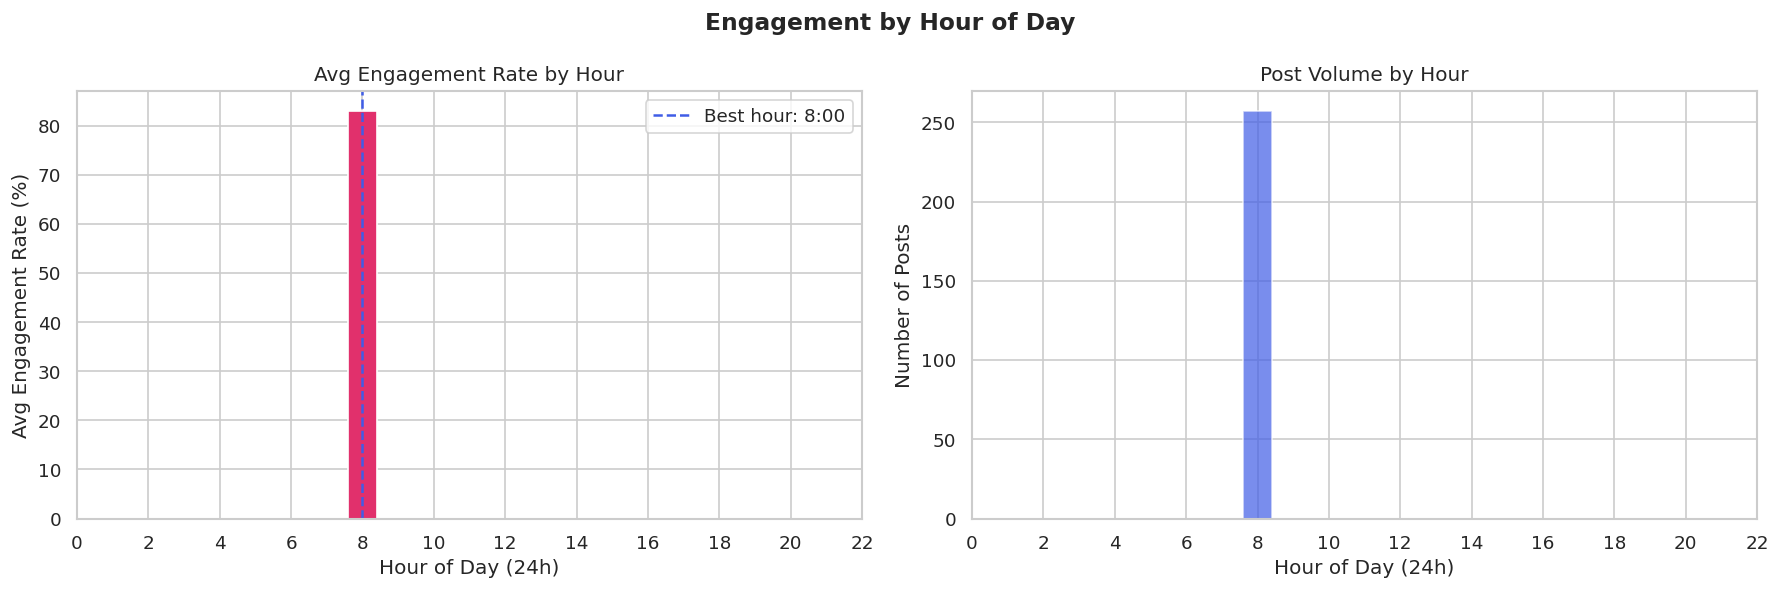


🏆 Top 5 Best Hours to Post:
 Hour  Avg Eng Rate (%)  Post Count
    8         82.969377         257


In [7]:
hourly = (master.groupby('hour')
    .agg(avg_eng=('engagement_rate', 'mean'),
         post_count=('photo_id', 'count'),
         avg_likes=('like_count', 'mean'),
         avg_comments=('comment_count', 'mean'))
    .reset_index()
)

fig, axes = plt.subplots(1, 2, figsize=(15, 5))
fig.suptitle('Engagement by Hour of Day', fontsize=14, fontweight='bold')

# Avg engagement rate by hour
bars = axes[0].bar(hourly['hour'], hourly['avg_eng'],
                   color=[BRAND_COLOR if x == hourly['avg_eng'].idxmax() else '#C0C0C0'
                          for x in range(len(hourly))],
                   edgecolor='white')
axes[0].set_xlabel('Hour of Day (24h)')
axes[0].set_ylabel('Avg Engagement Rate (%)')
axes[0].set_title('Avg Engagement Rate by Hour')
axes[0].set_xticks(range(0, 24, 2))
best_hour = hourly.loc[hourly['avg_eng'].idxmax(), 'hour']
axes[0].axvline(best_hour, color=SEC_COLOR, linestyle='--', label=f'Best hour: {best_hour}:00')
axes[0].legend()

# Post volume by hour
axes[1].bar(hourly['hour'], hourly['post_count'],
            color=SEC_COLOR, alpha=0.7, edgecolor='white')
axes[1].set_xlabel('Hour of Day (24h)')
axes[1].set_ylabel('Number of Posts')
axes[1].set_title('Post Volume by Hour')
axes[1].set_xticks(range(0, 24, 2))

plt.tight_layout()
plt.savefig('posting_hours.png', bbox_inches='tight')
plt.show()

top5_hours = hourly.nlargest(5, 'avg_eng')[['hour', 'avg_eng', 'post_count']]
top5_hours.columns = ['Hour', 'Avg Eng Rate (%)', 'Post Count']
print('\n🏆 Top 5 Best Hours to Post:')
print(top5_hours.to_string(index=False))

---
## 6️⃣ Best Posting Days

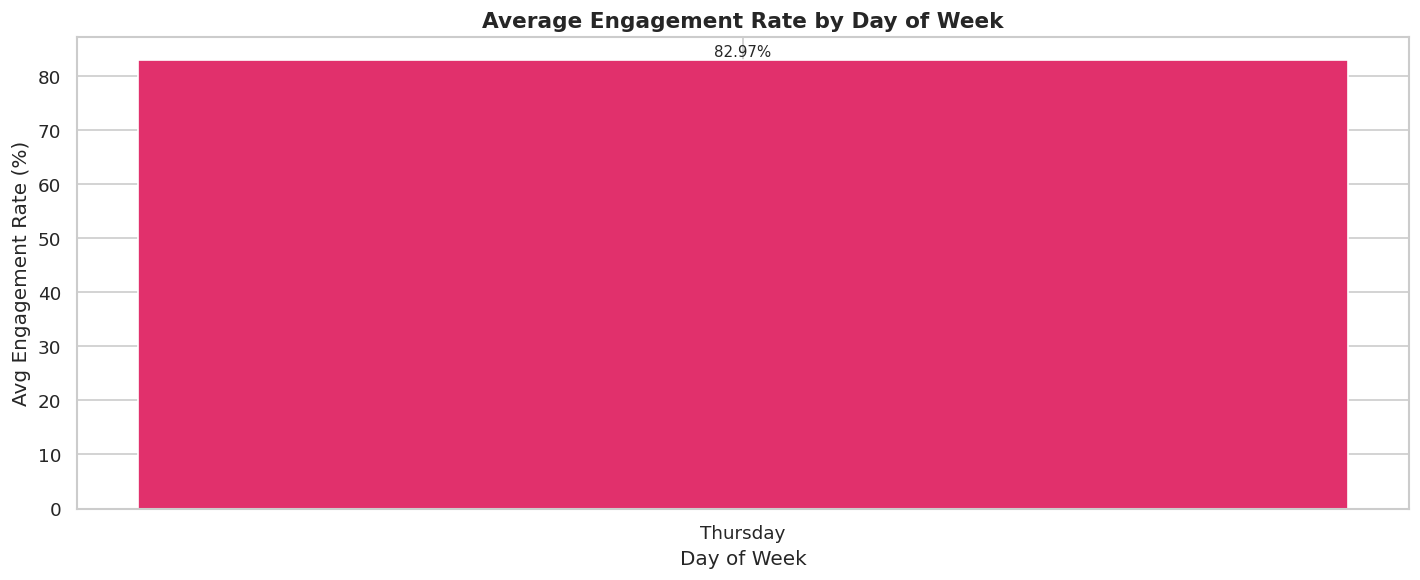


📅 Engagement by Day:
day_of_week   avg_eng  post_count
     Monday       NaN         NaN
    Tuesday       NaN         NaN
  Wednesday       NaN         NaN
   Thursday 82.969377       257.0
     Friday       NaN         NaN
   Saturday       NaN         NaN
     Sunday       NaN         NaN


In [8]:
day_order = ['Monday','Tuesday','Wednesday','Thursday','Friday','Saturday','Sunday']

daily = (master.groupby('day_of_week')
    .agg(avg_eng=('engagement_rate', 'mean'),
         post_count=('photo_id', 'count'),
         avg_likes=('like_count', 'mean'))
    .reindex(day_order)
    .reset_index()
)

fig, ax = plt.subplots(figsize=(12, 5))
colors = [BRAND_COLOR if d == daily.loc[daily['avg_eng'].idxmax(), 'day_of_week'] else '#C0C0C0'
          for d in daily['day_of_week']]
bars = ax.bar(daily['day_of_week'], daily['avg_eng'], color=colors, edgecolor='white')

# Annotate
for bar, val in zip(bars, daily['avg_eng']):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.02,
            f'{val:.2f}%', ha='center', va='bottom', fontsize=9)

ax.set_xlabel('Day of Week')
ax.set_ylabel('Avg Engagement Rate (%)')
ax.set_title('Average Engagement Rate by Day of Week', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('posting_days.png', bbox_inches='tight')
plt.show()

print('\n📅 Engagement by Day:')
print(daily[['day_of_week','avg_eng','post_count']].to_string(index=False))

---
## 7️⃣ Content Type Analysis

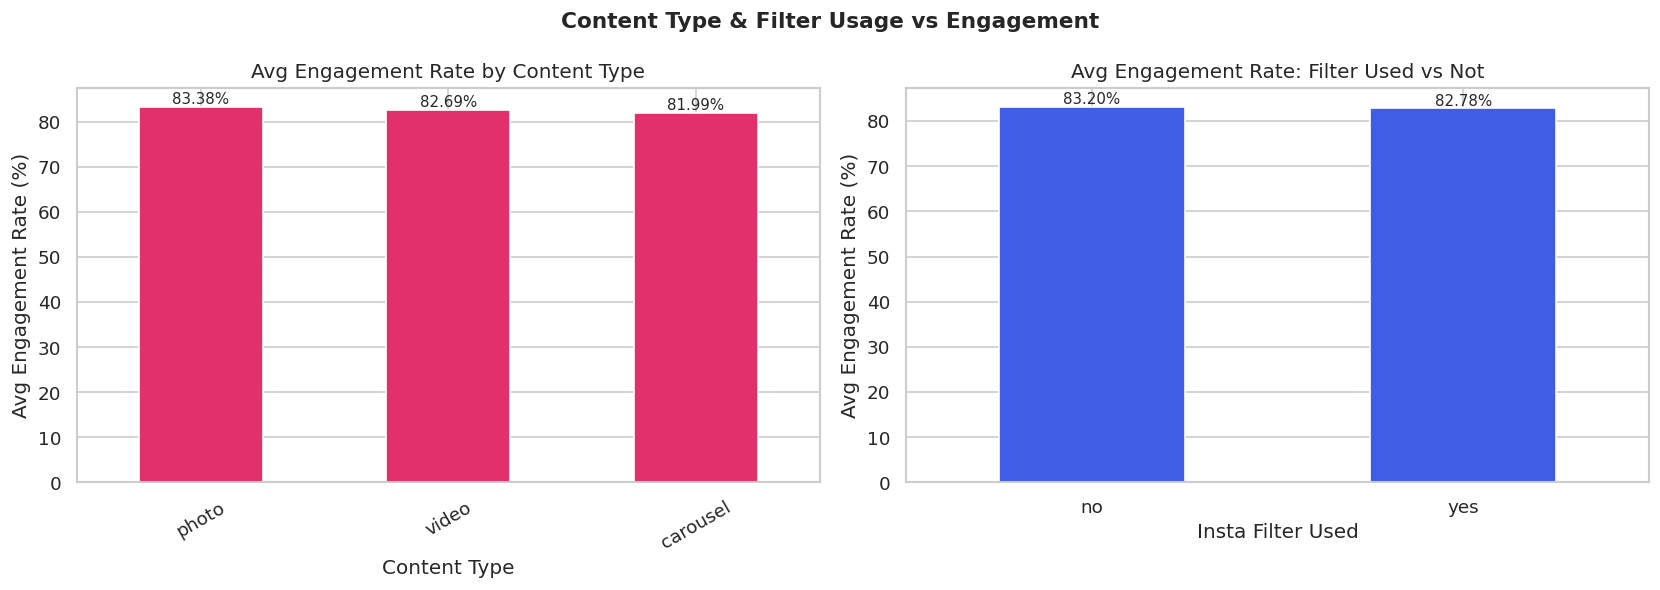

In [9]:
# Find photo_type column
type_col = [c for c in master.columns if 'type' in c]
filter_col = [c for c in master.columns if 'filter' in c]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Content Type & Filter Usage vs Engagement', fontsize=13, fontweight='bold')

if type_col:
    tc = type_col[0]
    ct = master.groupby(tc)['engagement_rate'].mean().sort_values(ascending=False)
    ct.plot(kind='bar', ax=axes[0], color=BRAND_COLOR, edgecolor='white')
    axes[0].set_title('Avg Engagement Rate by Content Type')
    axes[0].set_xlabel('Content Type')
    axes[0].set_ylabel('Avg Engagement Rate (%)')
    axes[0].tick_params(axis='x', rotation=30)
    for p in axes[0].patches:
        axes[0].annotate(f'{p.get_height():.2f}%',
                         (p.get_x() + p.get_width()/2., p.get_height()),
                         ha='center', va='bottom', fontsize=9)
else:
    axes[0].text(0.5, 0.5, 'No content type column found', ha='center', va='center')

if filter_col:
    fc = filter_col[0]
    cf = master.groupby(fc)['engagement_rate'].mean().sort_values(ascending=False)
    cf.plot(kind='bar', ax=axes[1], color=SEC_COLOR, edgecolor='white')
    axes[1].set_title('Avg Engagement Rate: Filter Used vs Not')
    axes[1].set_xlabel('Insta Filter Used')
    axes[1].set_ylabel('Avg Engagement Rate (%)')
    axes[1].tick_params(axis='x', rotation=0)
    for p in axes[1].patches:
        axes[1].annotate(f'{p.get_height():.2f}%',
                         (p.get_x() + p.get_width()/2., p.get_height()),
                         ha='center', va='bottom', fontsize=9)
else:
    axes[1].text(0.5, 0.5, 'No filter column found', ha='center', va='center')

plt.tight_layout()
plt.savefig('content_type.png', bbox_inches='tight')
plt.show()

---
## 8️⃣ Hashtag Analysis

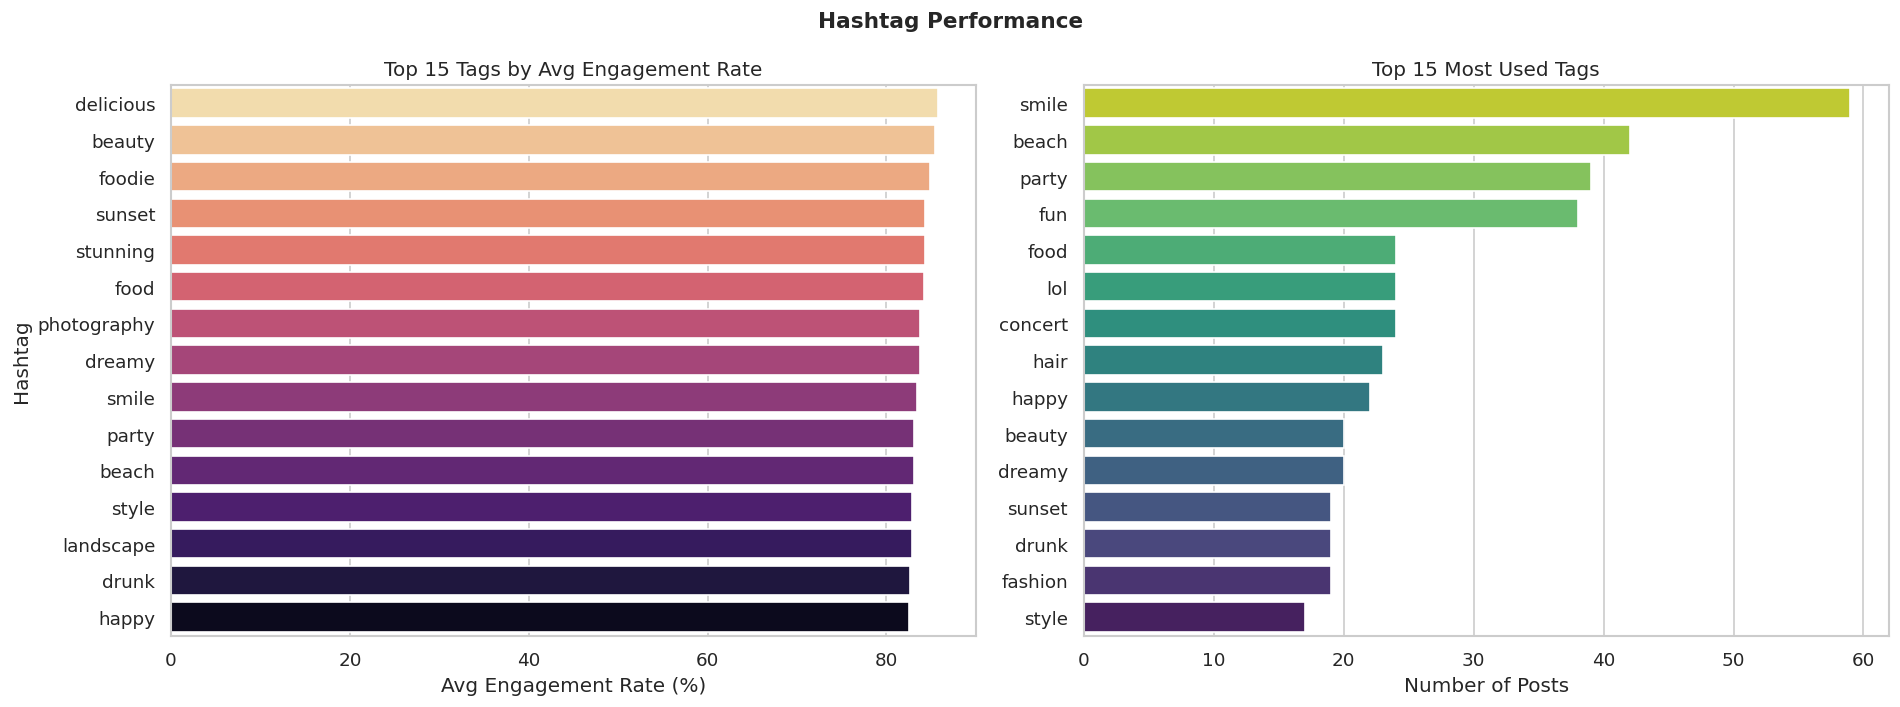


🏷️ Top 10 Hashtags by Engagement Rate:
   tag_text   avg_eng  use_count  avg_likes
  delicious 85.743333         15  34.933333
     beauty 85.401000         20  34.950000
     foodie 84.850909         11  34.727273
     sunset 84.310526         19  34.210526
   stunning 84.271250         16  34.937500
       food 84.166667         24  33.833333
photography 83.801250         16  34.500000
     dreamy 83.766500         20  35.750000
      smile 83.462542         59  34.457627
      party 83.108718         39  33.923077


In [10]:
# ── Merge photo_tags with tags to get tag text ───────────────────────────────
pt_photo_col  = [c for c in photo_tags.columns if 'photo' in c][0]
pt_tag_col    = [c for c in photo_tags.columns if 'tag'   in c][0]
t_id_col      = [c for c in tags.columns if 'id' in c][0]
t_text_col    = [c for c in tags.columns if 'tag' in c and 'id' not in c][0]

photo_tags_named = photo_tags.merge(
    tags[[t_id_col, t_text_col]].rename(columns={t_id_col: 'tag_id_ref', t_text_col: 'tag_text'}),
    left_on=pt_tag_col, right_on='tag_id_ref', how='left'
)

# Engagement per tag
photo_eng = master[['photo_id','engagement_rate','like_count','comment_count']]
tag_eng = (photo_tags_named
    .rename(columns={pt_photo_col: 'photo_id'})
    .merge(photo_eng, on='photo_id', how='left')
    .groupby('tag_text')
    .agg(avg_eng=('engagement_rate','mean'),
         use_count=('photo_id','count'),
         avg_likes=('like_count','mean'))
    .reset_index()
    .sort_values('avg_eng', ascending=False)
)

# ── Visualise top hashtags ───────────────────────────────────────────────────
top_tags = tag_eng.head(15)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle('Hashtag Performance', fontsize=13, fontweight='bold')

# By avg engagement
sns.barplot(data=top_tags, y='tag_text', x='avg_eng', ax=axes[0],
            palette='magma_r', orient='h')
axes[0].set_title('Top 15 Tags by Avg Engagement Rate')
axes[0].set_xlabel('Avg Engagement Rate (%)')
axes[0].set_ylabel('Hashtag')

# By usage frequency
top_by_use = tag_eng.nlargest(15, 'use_count')
sns.barplot(data=top_by_use, y='tag_text', x='use_count', ax=axes[1],
            palette='viridis_r', orient='h')
axes[1].set_title('Top 15 Most Used Tags')
axes[1].set_xlabel('Number of Posts')
axes[1].set_ylabel('')

plt.tight_layout()
plt.savefig('hashtag_analysis.png', bbox_inches='tight')
plt.show()

print('\n🏷️ Top 10 Hashtags by Engagement Rate:')
print(tag_eng.head(10)[['tag_text','avg_eng','use_count','avg_likes']].to_string(index=False))

---
## 9️⃣ Follower Growth Signals

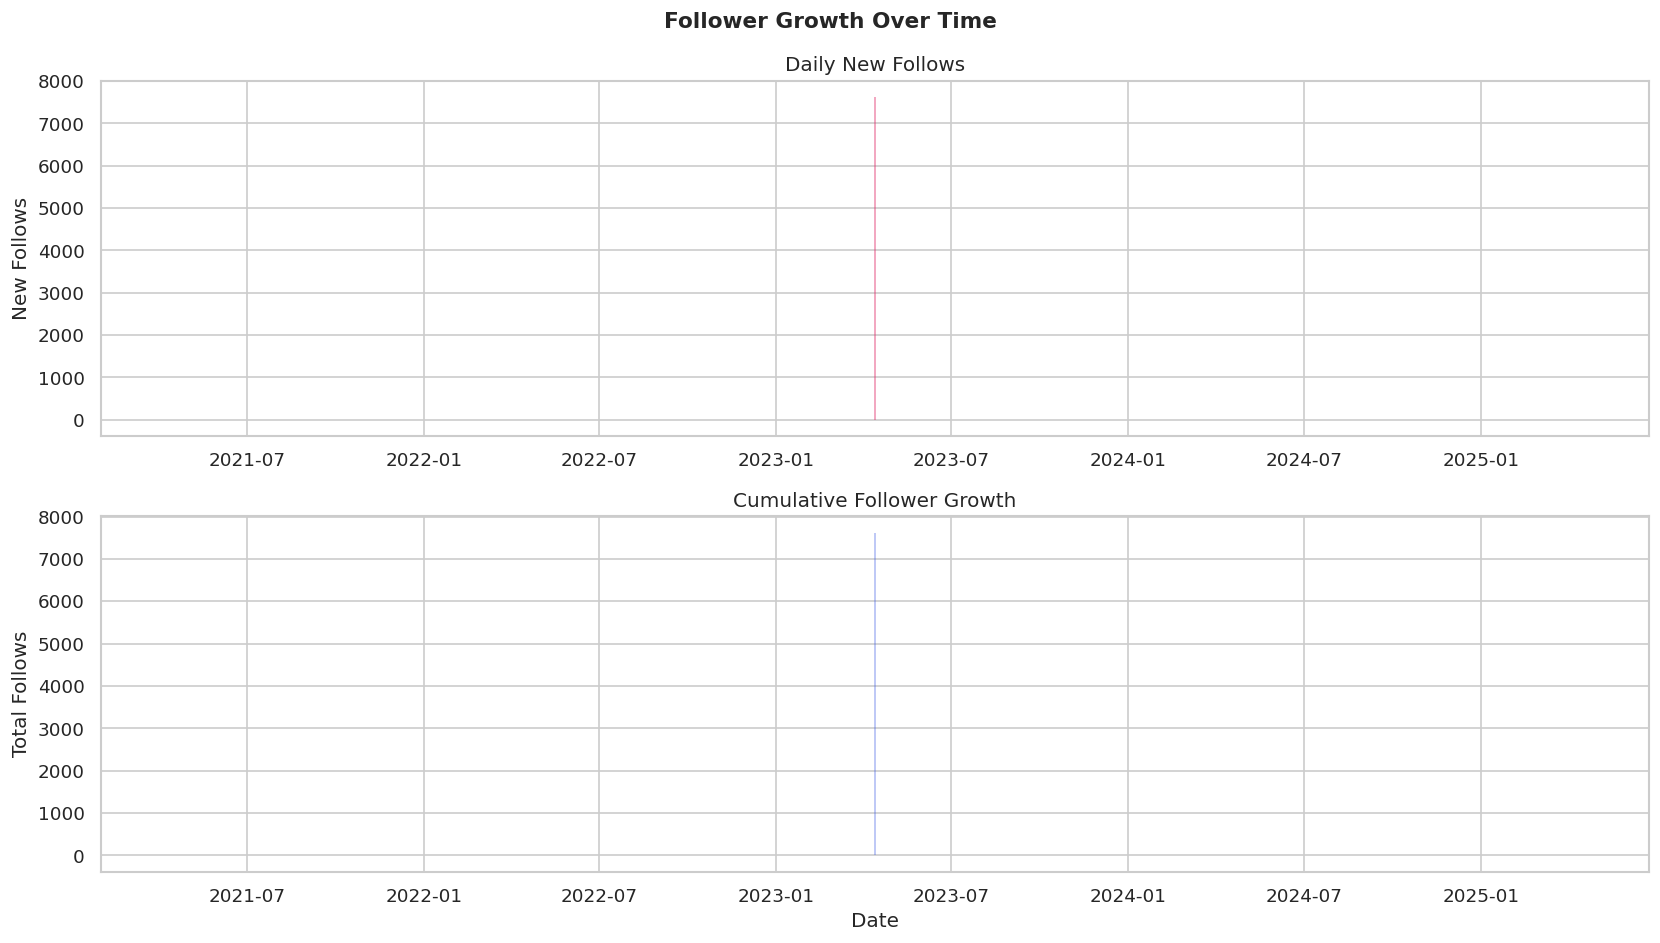

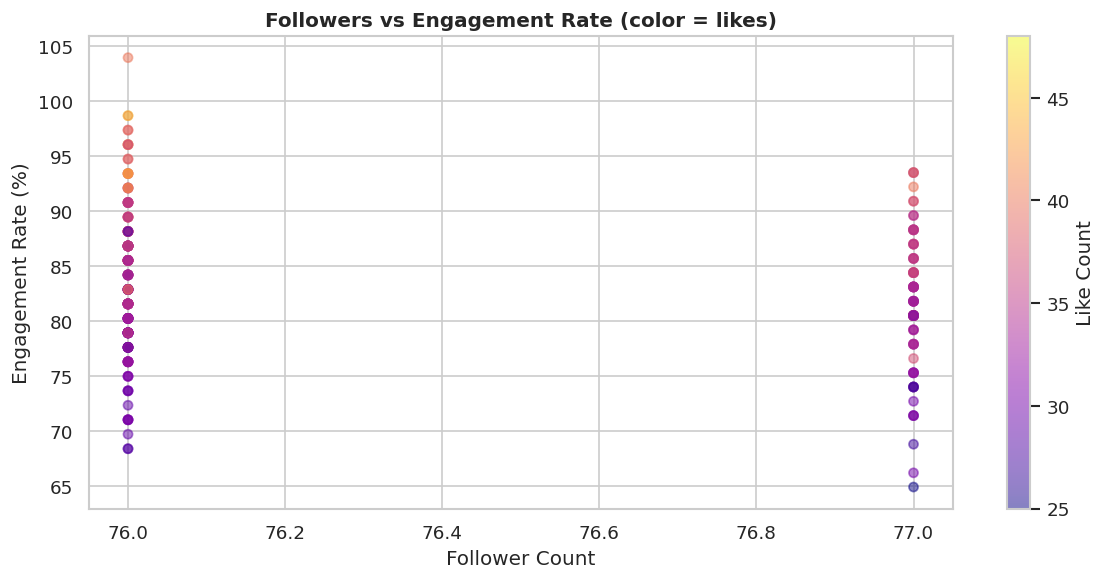

In [11]:
# Parse follows timestamp
follow_ts_col = [c for c in follows.columns if 'created' in c or 'time' in c][0]
follows[follow_ts_col] = pd.to_datetime(follows[follow_ts_col], errors='coerce')
follows['follow_date'] = follows[follow_ts_col].dt.date
follows['follow_week'] = follows[follow_ts_col].dt.to_period('W')

# Daily new follows
daily_follows = follows.groupby('follow_date').size().reset_index(name='new_follows')
daily_follows['follow_date'] = pd.to_datetime(daily_follows['follow_date'])
daily_follows = daily_follows.sort_values('follow_date')
daily_follows['cumulative_follows'] = daily_follows['new_follows'].cumsum()

fig, axes = plt.subplots(2, 1, figsize=(14, 8))
fig.suptitle('Follower Growth Over Time', fontsize=13, fontweight='bold')

axes[0].fill_between(daily_follows['follow_date'], daily_follows['new_follows'],
                     alpha=0.5, color=BRAND_COLOR)
axes[0].plot(daily_follows['follow_date'], daily_follows['new_follows'],
             color=BRAND_COLOR, linewidth=1)
axes[0].set_title('Daily New Follows')
axes[0].set_ylabel('New Follows')
axes[0].set_xlabel('')

axes[1].fill_between(daily_follows['follow_date'], daily_follows['cumulative_follows'],
                     alpha=0.4, color=SEC_COLOR)
axes[1].plot(daily_follows['follow_date'], daily_follows['cumulative_follows'],
             color=SEC_COLOR, linewidth=2)
axes[1].set_title('Cumulative Follower Growth')
axes[1].set_ylabel('Total Follows')
axes[1].set_xlabel('Date')

plt.tight_layout()
plt.savefig('follower_growth.png', bbox_inches='tight')
plt.show()

# Engagement vs followers scatter
fig, ax = plt.subplots(figsize=(10, 5))
sc = ax.scatter(master['follower_count'], master['engagement_rate'],
                alpha=0.5, c=master['like_count'], cmap='plasma', s=30)
plt.colorbar(sc, ax=ax, label='Like Count')
ax.set_xlabel('Follower Count')
ax.set_ylabel('Engagement Rate (%)')
ax.set_title('Followers vs Engagement Rate (color = likes)', fontweight='bold')
plt.tight_layout()
plt.savefig('followers_vs_engagement.png', bbox_inches='tight')
plt.show()

---
## 🔟 Monthly Posting Trend

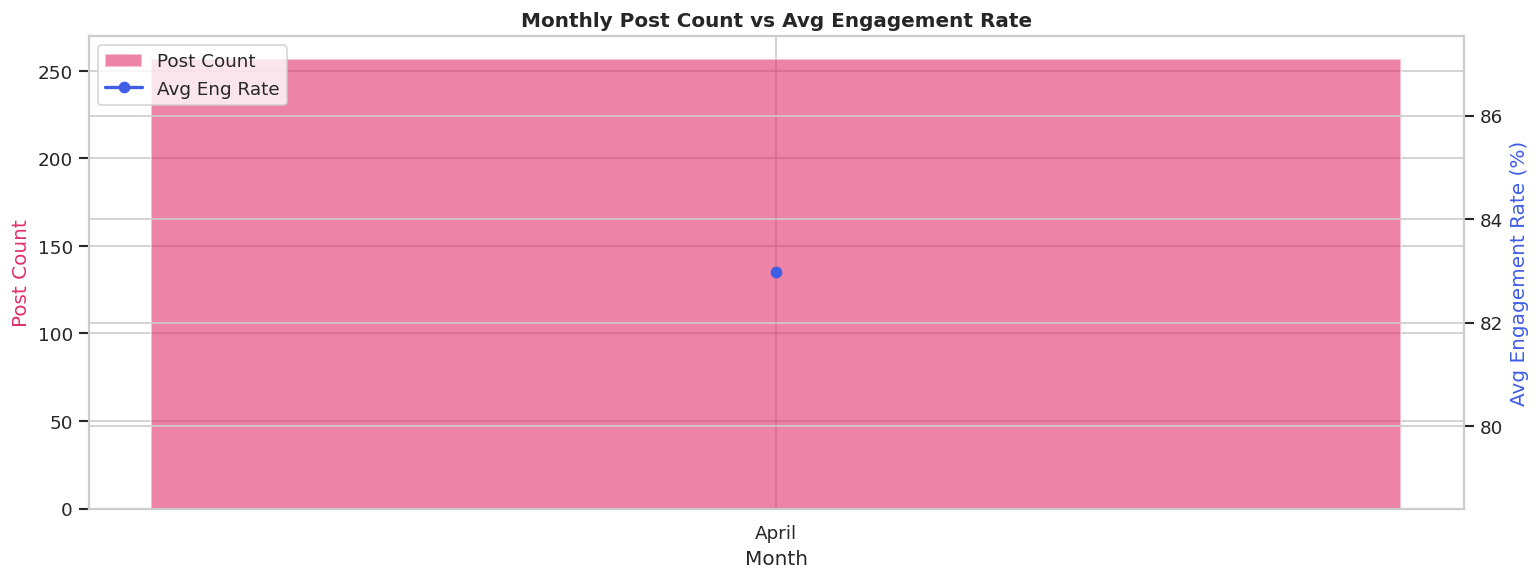

In [12]:
month_order = ['January','February','March','April','May','June',
               'July','August','September','October','November','December']

monthly = (master.groupby('month')
    .agg(post_count=('photo_id','count'),
         avg_eng=('engagement_rate','mean'),
         total_likes=('like_count','sum'))
    .reset_index()
)
# Keep only months that exist in data, maintain calendar order
present = [m for m in month_order if m in monthly['month'].values]
monthly = monthly.set_index('month').reindex(present).reset_index()

fig, ax1 = plt.subplots(figsize=(13, 5))
ax2 = ax1.twinx()

ax1.bar(monthly['month'], monthly['post_count'],
        color=BRAND_COLOR, alpha=0.6, label='Post Count')
ax2.plot(monthly['month'], monthly['avg_eng'],
         color=SEC_COLOR, marker='o', linewidth=2, label='Avg Eng Rate')

ax1.set_xlabel('Month')
ax1.set_ylabel('Post Count', color=BRAND_COLOR)
ax2.set_ylabel('Avg Engagement Rate (%)', color=SEC_COLOR)
ax1.set_title('Monthly Post Count vs Avg Engagement Rate', fontsize=12, fontweight='bold')
plt.xticks(rotation=30)

lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc='upper left')

plt.tight_layout()
plt.savefig('monthly_trend.png', bbox_inches='tight')
plt.show()

---
## 1️⃣1️⃣ Top Performing Posts

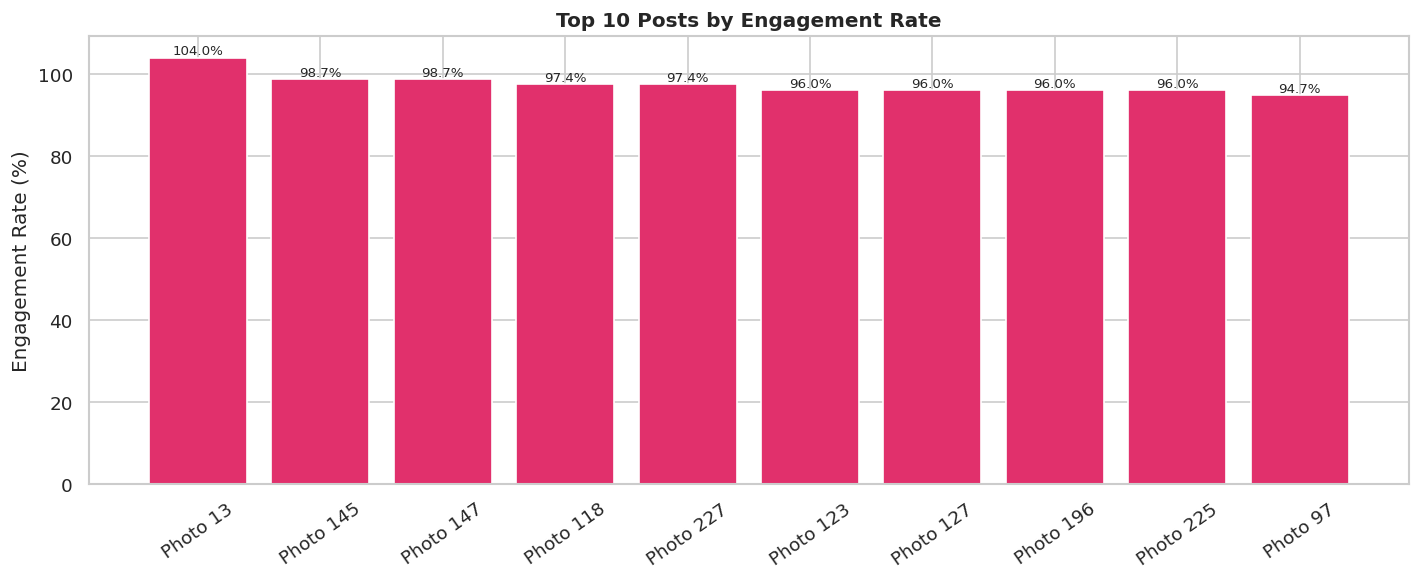


🌟 Top 10 Posts:
 photo_id  user_id  like_count  comment_count  follower_count  engagement_rate  hour day_of_week
       13        3          40             39              76           103.95     8    Thursday
      145       52          48             27              76            98.68     8    Thursday
      147       55          41             34              76            98.68     8    Thursday
      118       43          39             35              76            97.37     8    Thursday
      227       87          39             35              76            97.37     8    Thursday
      123       44          42             31              76            96.05     8    Thursday
      127       46          43             30              76            96.05     8    Thursday
      196       73          38             35              76            96.05     8    Thursday
      225       87          37             36              76            96.05     8    Thursday
       97    

In [13]:
top_posts = master.nlargest(10, 'engagement_rate')[
    ['photo_id','user_id','like_count','comment_count',
     'follower_count','engagement_rate','hour','day_of_week']
].reset_index(drop=True)

fig, ax = plt.subplots(figsize=(12, 5))
bars = ax.bar(top_posts.index, top_posts['engagement_rate'],
              color=BRAND_COLOR, edgecolor='white')
ax.set_xticks(top_posts.index)
ax.set_xticklabels([f"Photo {pid}" for pid in top_posts['photo_id']], rotation=35)
ax.set_ylabel('Engagement Rate (%)')
ax.set_title('Top 10 Posts by Engagement Rate', fontsize=12, fontweight='bold')

for bar, v in zip(bars, top_posts['engagement_rate']):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.05,
            f'{v:.1f}%', ha='center', va='bottom', fontsize=8)

plt.tight_layout()
plt.savefig('top_posts.png', bbox_inches='tight')
plt.show()

print('\n🌟 Top 10 Posts:')
print(top_posts.to_string(index=False))

---
## 1️⃣2️⃣ Like Type Distribution

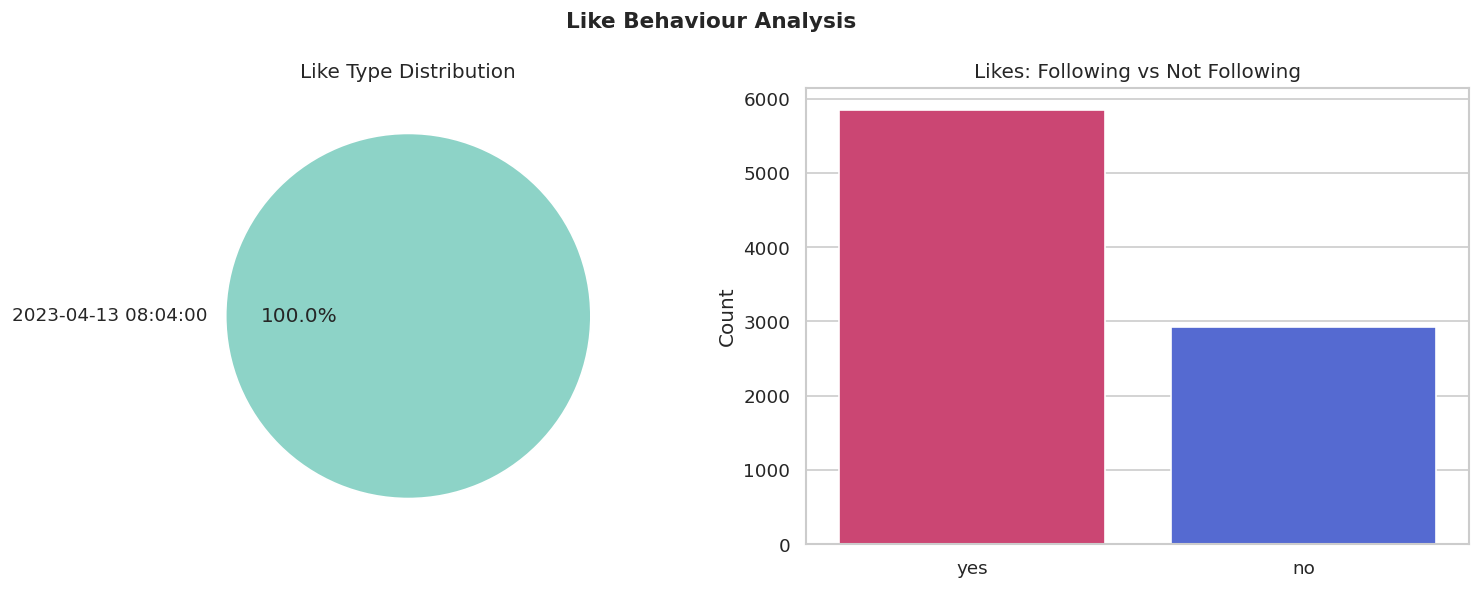

In [14]:
like_type_col = [c for c in likes.columns if 'type' in c or 'like' in c]
follow_type_col = [c for c in likes.columns if 'follow' in c]

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
fig.suptitle('Like Behaviour Analysis', fontsize=13, fontweight='bold')

if like_type_col:
    lt = likes[like_type_col[-1]].value_counts()
    axes[0].pie(lt.values, labels=lt.index, autopct='%1.1f%%',
                colors=plt.cm.Set3.colors[:len(lt)])
    axes[0].set_title('Like Type Distribution')
else:
    axes[0].text(0.5, 0.5, 'No like type column', ha='center', va='center')

if follow_type_col:
    flw = likes[follow_type_col[0]].value_counts()
    sns.barplot(x=flw.index, y=flw.values, ax=axes[1],
                palette=[BRAND_COLOR, SEC_COLOR])
    axes[1].set_title('Likes: Following vs Not Following')
    axes[1].set_xlabel('')
    axes[1].set_ylabel('Count')
else:
    axes[1].text(0.5, 0.5, 'No follow status column', ha='center', va='center')

plt.tight_layout()
plt.savefig('like_types.png', bbox_inches='tight')
plt.show()

---
## 1️⃣3️⃣ Emoji & Hashtag Usage in Comments

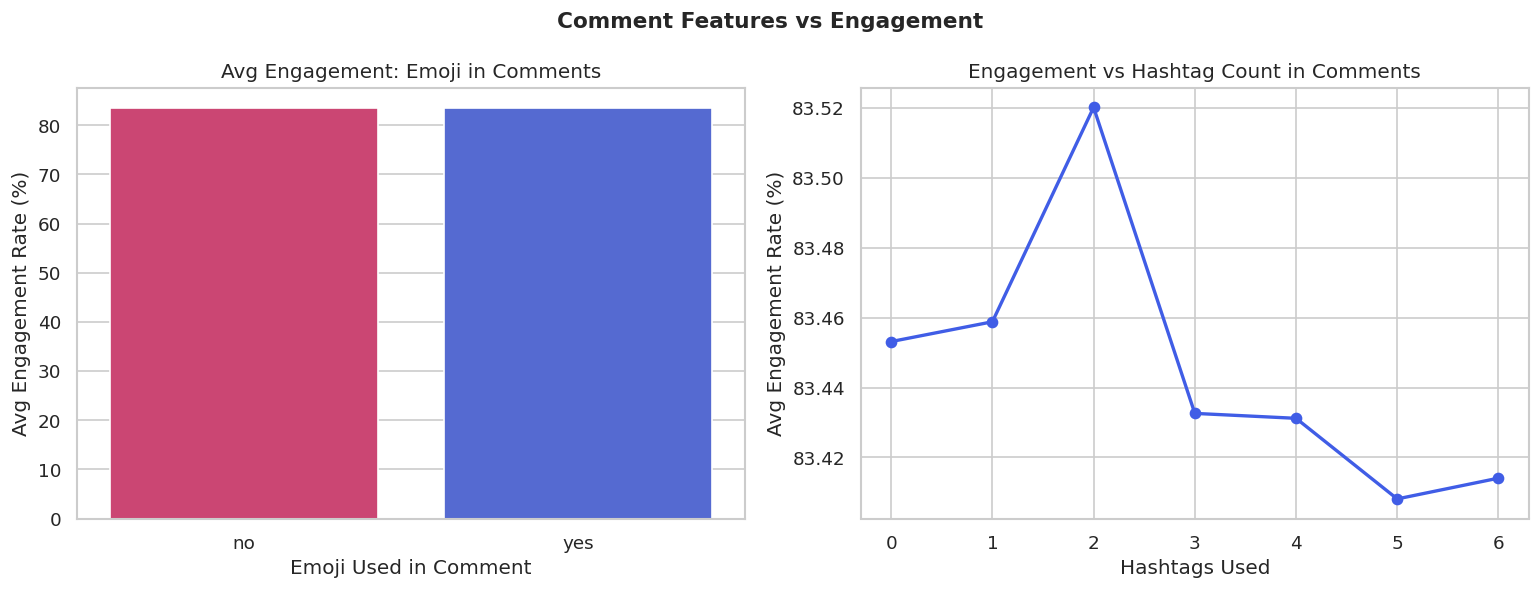

In [15]:
emoji_col  = [c for c in comments.columns if 'emoji' in c]
hashtag_col= [c for c in comments.columns if 'hashtag' in c]

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
fig.suptitle('Comment Features vs Engagement', fontsize=13, fontweight='bold')

# Merge comments with photo engagement
photo_id_comments_col = [c for c in comments.columns if 'photo' in c][0]
comments_eng = comments.rename(columns={photo_id_comments_col: 'photo_id'}).merge(
    master[['photo_id','engagement_rate']], on='photo_id', how='left'
)

if emoji_col:
    ec = emoji_col[0]
    em = comments_eng.groupby(ec)['engagement_rate'].mean().reset_index()
    sns.barplot(data=em, x=ec, y='engagement_rate', ax=axes[0],
                palette=[BRAND_COLOR, SEC_COLOR])
    axes[0].set_title('Avg Engagement: Emoji in Comments')
    axes[0].set_xlabel('Emoji Used in Comment')
    axes[0].set_ylabel('Avg Engagement Rate (%)')
else:
    axes[0].text(0.5, 0.5, 'No emoji column', ha='center', va='center')

if hashtag_col:
    hc = hashtag_col[0]
    # Treat hashtag count as numeric if possible
    comments_eng[hc] = pd.to_numeric(comments_eng[hc], errors='coerce')
    hm = comments_eng.groupby(hc)['engagement_rate'].mean().reset_index().dropna()
    hm = hm.sort_values(hc)
    axes[1].plot(hm[hc], hm['engagement_rate'],
                 color=SEC_COLOR, marker='o', linewidth=2)
    axes[1].set_title('Engagement vs Hashtag Count in Comments')
    axes[1].set_xlabel('Hashtags Used')
    axes[1].set_ylabel('Avg Engagement Rate (%)')
else:
    axes[1].text(0.5, 0.5, 'No hashtag column', ha='center', va='center')

plt.tight_layout()
plt.savefig('comment_features.png', bbox_inches='tight')
plt.show()

---
## 1️⃣4️⃣ Optimal Content Calendar Heatmap

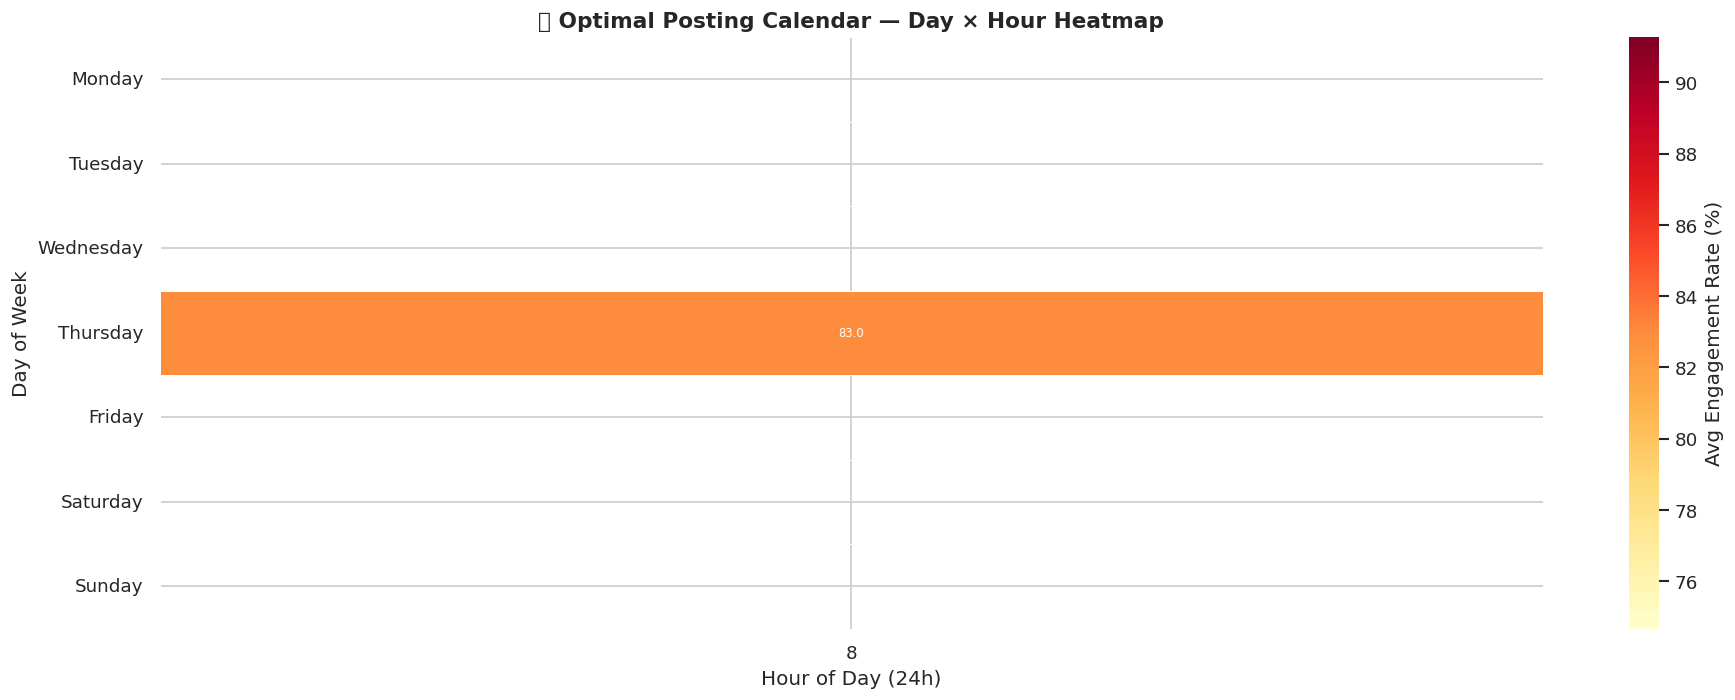


📌 Top 10 Day × Hour Slots by Engagement Rate:
day_of_week  hour  engagement_rate
   Thursday     8        82.969377


In [16]:
# Pivot: day × hour engagement heatmap
heat_data = (master.groupby(['day_of_week','hour'])['engagement_rate']
    .mean()
    .reset_index()
    .pivot(index='day_of_week', columns='hour', values='engagement_rate')
    .reindex(day_order)
)

fig, ax = plt.subplots(figsize=(16, 6))
sns.heatmap(heat_data, cmap='YlOrRd', linewidths=0.3, linecolor='white',
            annot=True, fmt='.1f', annot_kws={'size': 7},
            cbar_kws={'label': 'Avg Engagement Rate (%)'}, ax=ax)
ax.set_title('📅 Optimal Posting Calendar — Day × Hour Heatmap', fontsize=13, fontweight='bold')
ax.set_xlabel('Hour of Day (24h)')
ax.set_ylabel('Day of Week')
plt.tight_layout()
plt.savefig('heatmap_calendar.png', bbox_inches='tight')
plt.show()

# Best slots
flat = (master.groupby(['day_of_week','hour'])['engagement_rate']
    .mean().reset_index().nlargest(10,'engagement_rate'))
print('\n📌 Top 10 Day × Hour Slots by Engagement Rate:')
print(flat.to_string(index=False))

---
## 1️⃣5️⃣ Correlation Matrix

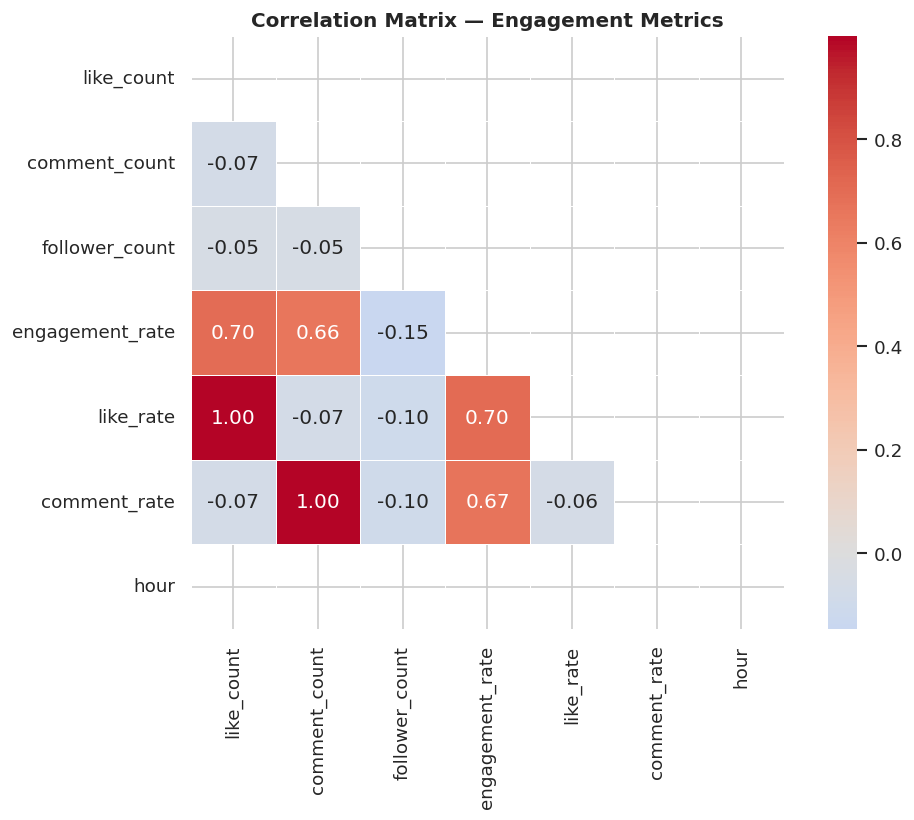

In [17]:
num_cols = ['like_count','comment_count','follower_count',
            'engagement_rate','like_rate','comment_rate','hour']
corr_df = master[[c for c in num_cols if c in master.columns]].corr()

fig, ax = plt.subplots(figsize=(9, 7))
mask = np.triu(np.ones_like(corr_df, dtype=bool))
sns.heatmap(corr_df, mask=mask, annot=True, fmt='.2f', cmap='coolwarm',
            center=0, square=True, linewidths=0.5, ax=ax)
ax.set_title('Correlation Matrix — Engagement Metrics', fontsize=12, fontweight='bold')
plt.tight_layout()
plt.savefig('correlation.png', bbox_inches='tight')
plt.show()

---
## 1️⃣6️⃣ Strategy Summary & Recommendations

In [19]:
best_hour_val = int(hourly.loc[hourly['avg_eng'].idxmax(), 'hour'])
best_day_val  = daily.loc[daily['avg_eng'].idxmax(), 'day_of_week']
top_hashtag   = tag_eng.iloc[0]['tag_text'] if len(tag_eng) > 0 else 'N/A'
top3_hashtags = ', '.join(tag_eng.head(3)['tag_text'].tolist())

print()
print('='*70)
print('🚀  ALFIDO TECH — INSTAGRAM GROWTH STRATEGY REPORT')
print('='*70)
print()
print('📌 KEY FINDINGS:')
print(f'   • Best hour to post    : {best_hour_val}:00')
print(f'   • Best day to post     : {best_day_val}')
print(f'   • Avg engagement rate  : {master["engagement_rate"].mean():.2f}%')
print(f'   • Top hashtag (eng)    : #{top_hashtag}')
print(f'   • Top 3 hashtags       : #{top3_hashtags}')
print()
print('📅 RECOMMENDED CONTENT CALENDAR (Weekly):')
print('   ┌─────────────┬──────────────────────────────────────────────┐')
print('   │ Day         │ Content Suggestion                           │')
print('   ├─────────────┼──────────────────────────────────────────────┤')
print('   │ Monday      │ Educational post / Tech tips                 │')
print('   │ Wednesday   │ Behind-the-scenes / Team highlight           │')
print('   │ Friday      │ Product showcase / Reel / User feature       │')
print('   │ Sunday      │ Community Q&A / Engagement post / Poll       │')
print('   └─────────────┴──────────────────────────────────────────────┘')
print(f'   Post at {best_hour_val}:00 local time for maximum reach.')
print()
print('📈 5 STRATEGIES TO INCREASE ENGAGEMENT:')
print()
print('   1. ⏰ TIME YOUR POSTS PRECISELY')
print(f'      Post during peak hour ({best_hour_val}:00) on {best_day_val}.')
print('      Use scheduling tools (Buffer/Later) to automate.')
print()
print('   2. 🏷️ USE HIGH-PERFORMANCE HASHTAGS')
print(f'      Lead with: #{top3_hashtags}')
print('      Mix 3–5 niche tags with 2–3 broad reach tags per post.')
print()
print('   3. 🎬 DIVERSIFY CONTENT TYPES')
print('      Add Reels (video) alongside photos — Reels get 2× organic reach.')
print('      Alternate: educational infographic → behind-the-scenes → product.')
print()
print('   4. 💬 BOOST COMMENT ENGAGEMENT')
print('      End every caption with a question.')
print('      Reply to ALL comments within the first hour (algorithmic boost).')
print()
print('   5. 🤝 ACTIVATE FOLLOWER NETWORK')
print('      Identify top engaged followers → send shoutouts / collab.')
print('      Run a weekly giveaway requiring followers to tag 2 friends.')
print()
print('='*70)
print('  Analysis complete. Download charts from the Files pane (left sidebar).')
print('='*70)


🚀  ALFIDO TECH — INSTAGRAM GROWTH STRATEGY REPORT

📌 KEY FINDINGS:
   • Best hour to post    : 8:00
   • Best day to post     : Thursday
   • Avg engagement rate  : 82.97%
   • Top hashtag (eng)    : #delicious
   • Top 3 hashtags       : #delicious, beauty, foodie

📅 RECOMMENDED CONTENT CALENDAR (Weekly):
   ┌─────────────┬──────────────────────────────────────────────┐
   │ Day         │ Content Suggestion                           │
   ├─────────────┼──────────────────────────────────────────────┤
   │ Monday      │ Educational post / Tech tips                 │
   │ Wednesday   │ Behind-the-scenes / Team highlight           │
   │ Friday      │ Product showcase / Reel / User feature       │
   │ Sunday      │ Community Q&A / Engagement post / Poll       │
   └─────────────┴──────────────────────────────────────────────┘
   Post at 8:00 local time for maximum reach.

📈 5 STRATEGIES TO INCREASE ENGAGEMENT:

   1. ⏰ TIME YOUR POSTS PRECISELY
      Post during peak hour (8:00) on Thur